# 🏎️ F1 Pit Stop Prediction — Improved Pipeline

This notebook predicts F1 pit stop timing using OpenF1 telemetry data.

**Two-stage model:**
1. **Binary model** — Will this driver pit within the next K laps? (classification)
2. **Regression model** — If so, how many laps until the stop? (regression, replacing the weak multiclass approach)

**Key improvements over v1:**
- ✅ Fixed race-end label bug (re-split after relabeling)
- ✅ New features: `laps_remaining`, `pits_taken_so_far`, `laps_since_last_sc`, session-normalised sector pace
- ✅ Conditional model changed from classification → regression (MAE-trained)
- ✅ Corrected class weights using post-relabel pit rate
- ✅ Temporal validation: train on 2023–2024, test on 2025
- ✅ Per-circuit accuracy analysis
- ✅ Inference helper function
- ✅ TensorFlow version fixed

## 1. Install & Imports

In [1]:
# Removed the pinned tensorflow==2.15.0 which doesn't exist — use whatever Colab provides
!pip -q install pandas numpy requests scikit-learn tqdm pyarrow
import tensorflow as tf
print('TF version:', tf.__version__)
assert int(tf.__version__.split('.')[0]) >= 2 and int(tf.__version__.split('.')[1]) >= 16, \
    'Need TF >= 2.16'

TF version: 2.19.0


In [2]:
import time, json, requests
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, mean_absolute_error
import tensorflow as tf
from tensorflow import keras

BASE_URL = 'https://api.openf1.org/v1'

# Years to fetch — 2026 will return empty and be skipped automatically
YEARS = [2023, 2024, 2025, 2026]
SESSION_NAME = 'Race'

# Pit prediction window: label = laps until next pit (0..K-1), or K for 'no pit'
K_WINDOW = 10

# API rate-limit polite sleep
SLEEP = 2.1
CACHE_DIR = Path('/content/openf1_cache'); CACHE_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('/content/models'); MODEL_DIR.mkdir(exist_ok=True)

print('Config ready. K_WINDOW =', K_WINDOW)

Config ready. K_WINDOW = 10


## 2. Data Fetching (with local file cache)

In [3]:
def cache_path(endpoint: str, params: dict) -> Path:
    safe = endpoint + '__' + '__'.join([f'{k}={params[k]}' for k in sorted(params)])
    safe = safe.replace('/', '_').replace(' ', '_')
    return CACHE_DIR / f'{safe}.json'


def get_openf1(endpoint: str, params: dict, retries: int = 3, force_refresh: bool = False):
    """Fetch from OpenF1 with disk cache. Set force_refresh=True to bypass cache."""
    p = cache_path(endpoint, params)
    if p.exists() and not force_refresh:
        return json.loads(p.read_text())

    url = f'{BASE_URL}/{endpoint}'
    last_err = None
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=60)
            if r.status_code == 404:
                data = []
                p.write_text(json.dumps(data))
                time.sleep(SLEEP)
                return data
            if r.status_code != 200:
                raise RuntimeError(f'{endpoint} -> {r.status_code}: {r.text[:200]}')
            data = r.json()
            p.write_text(json.dumps(data))
            time.sleep(SLEEP)
            return data
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f'Failed: {endpoint} {params}. Last error: {last_err}')


def list_race_sessions(year: int):
    sessions = get_openf1('sessions', {'year': year, 'session_name': SESSION_NAME})
    return sorted(sessions, key=lambda x: x.get('date_start', ''))


all_sessions = []
for y in YEARS:
    all_sessions += list_race_sessions(y)

sessions_df = pd.DataFrame(all_sessions)
print('Race sessions found:', len(sessions_df))
display(sessions_df[['year','country_name','circuit_short_name','session_key','date_start']].head(30))

session_keys = sessions_df['session_key'].astype(int).tolist()
session_meta = sessions_df.set_index('session_key')[['year','country_name','circuit_short_name']].to_dict('index')

Race sessions found: 95


,year,country_name,circuit_short_name,session_key,date_start
0,2023,Bahrain,Sakhir,7953,2023-03-05T15:00:00+00:00
1,2023,Saudi Arabia,Jeddah,7779,2023-03-19T17:00:00+00:00
2,2023,Australia,Melbourne,7787,2023-04-02T05:00:00+00:00
3,2023,Azerbaijan,Baku,9070,2023-04-30T11:00:00+00:00
4,2023,United States,Miami,9078,2023-05-07T19:30:00+00:00
5,2023,Italy,Imola,9086,2023-05-21T13:00:00+00:00
6,2023,Monaco,Monte Carlo,9094,2023-05-28T13:00:00+00:00
7,2023,Spain,Catalunya,9102,2023-06-04T13:00:00+00:00
8,2023,Canada,Montreal,9110,2023-06-18T18:00:00+00:00
9,2023,Austria,Spielberg,9118,2023-07-02T13:00:00+00:00


In [4]:
def snapshot_session(session_key: int):
    laps      = get_openf1('laps',        {'session_key': session_key})
    stints    = get_openf1('stints',      {'session_key': session_key})
    drivers   = get_openf1('drivers',     {'session_key': session_key})
    intervals = get_openf1('intervals',   {'session_key': session_key})
    weather   = get_openf1('weather',     {'session_key': session_key})
    race_ctrl = get_openf1('race_control',{'session_key': session_key})
    return laps, stints, drivers, intervals, weather, race_ctrl


snapshots = {}
skipped   = []

for sk in tqdm(session_keys, desc='Downloading sessions'):
    sk = int(sk)
    laps, stints, drivers, intervals, weather, race_ctrl = snapshot_session(sk)
    if not laps or not stints or not drivers:
        skipped.append(sk)
        continue
    snapshots[sk] = {
        'laps': laps, 'stints': stints, 'drivers': drivers,
        'intervals': intervals, 'weather': weather,
        'race_control': race_ctrl, 'meta': session_meta.get(sk, {})
    }

print('Kept sessions:', len(snapshots))
print('Skipped:', len(skipped), 'example:', skipped[:5])

Kept sessions: 70
Skipped: 25 example: [9086, 11234, 11245, 11253, 11261]


## 3. Feature Engineering

New features added vs v1:
- `laps_remaining` — crucial for end-of-race context
- `pits_taken_so_far` — number of stops already made (stint index)
- `laps_since_last_sc` — decaying safety car relevance
- `sector_pace_vs_session` — sector time normalised by session median (cross-circuit comparable)
- `lap_duration_vs_session` — same for full lap time

In [5]:
def _to_dt(s):
    return pd.to_datetime(s, utc=True, errors='coerce')


def _gap_to_float(x):
    if x is None:
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if isinstance(x, str):
        t = x.strip()
        if not t or t.lower() == 'null':
            return np.nan
        if 'LAP' in t.upper():
            return 99.0
        if t.startswith('+'):
            t = t[1:]
        try:
            return float(t)
        except:
            return np.nan
    return np.nan


def build_session_dataframe(pack, k_window=10):
    laps       = pd.DataFrame(pack.get('laps', []))
    stints_raw = pd.DataFrame(pack.get('stints', []))
    drivers    = pd.DataFrame(pack.get('drivers', []))
    intervals  = pd.DataFrame(pack.get('intervals', []))
    weather    = pd.DataFrame(pack.get('weather', []))
    rc         = pd.DataFrame(pack.get('race_control', []))

    if laps.empty or stints_raw.empty or drivers.empty:
        return pd.DataFrame()

    # --- Stints
    stints = stints_raw.copy().rename(columns={
        'lap_start':         'stint_lap_start',
        'lap_end':           'stint_lap_end',
        'compound':          'stint_compound',
        'tyre_age_at_start': 'stint_tyre_age_at_start'
    })

    # --- Laps essentials
    must = ['driver_number', 'lap_number', 'lap_duration', 'date_start']
    if any(c not in laps.columns for c in must):
        return pd.DataFrame()

    laps = laps.copy()
    laps['date_start']   = _to_dt(laps['date_start'])
    laps['lap_duration'] = pd.to_numeric(laps['lap_duration'], errors='coerce')
    laps = laps.dropna(subset=['date_start', 'lap_duration'])

    for c in ['duration_sector_1', 'duration_sector_2', 'duration_sector_3']:
        laps[c] = pd.to_numeric(laps.get(c, np.nan), errors='coerce')

    # --- Join laps → stints
    join_keys = [k for k in ['session_key', 'meeting_key', 'driver_number']
                 if k in laps.columns and k in stints.columns] or ['driver_number']
    merged = laps.merge(stints, on=join_keys, how='left')
    merged = merged[
        (merged['lap_number'] >= merged['stint_lap_start']) &
        (merged['lap_number'] <= merged['stint_lap_end'])
    ].copy()

    merged['stint_age'] = merged['lap_number'] - merged['stint_lap_start']
    merged['compound']  = merged.get('stint_compound', 'UNKNOWN').fillna('UNKNOWN').astype(str)
    merged['tyre_age_at_start'] = pd.to_numeric(
        merged.get('stint_tyre_age_at_start', 0.0), errors='coerce').fillna(0.0)

    merged = merged.sort_values(['driver_number', 'lap_number']).reset_index(drop=True)

    # --- Previous-lap pace (avoids leaking current pit-lap duration)
    g = merged.groupby('driver_number')
    merged['lap_duration_prev'] = g['lap_duration'].shift(1).fillna(merged['lap_duration'])
    merged['sector1_prev']      = g['duration_sector_1'].shift(1).fillna(0.0)
    merged['sector2_prev']      = g['duration_sector_2'].shift(1).fillna(0.0)
    merged['sector3_prev']      = g['duration_sector_3'].shift(1).fillna(0.0)

    # Rolling pace trend
    merged['lap_mean_last3'] = g['lap_duration'].transform(
        lambda s: s.shift(1).rolling(3).mean()
    ).fillna(merged['lap_duration_prev'])

    def slope_last3(s):
        def _slope(v):
            return np.polyfit([0,1,2], v, 1)[0] if len(v) == 3 else np.nan
        return s.shift(1).rolling(3).apply(_slope, raw=False)

    merged['lap_slope_last3'] = g['lap_duration'].transform(slope_last3).fillna(0.0)

    # ✅ NEW: session-normalised pace (comparable across circuits)
    session_median_lap = merged['lap_duration'].median()
    session_median_s1  = merged['duration_sector_1'].median()
    session_median_s2  = merged['duration_sector_2'].median()
    session_median_s3  = merged['duration_sector_3'].median()
    merged['lap_vs_session']      = merged['lap_duration_prev'] / (session_median_lap + 1e-9)
    merged['sector1_vs_session']  = merged['sector1_prev']      / (session_median_s1  + 1e-9)
    merged['sector2_vs_session']  = merged['sector2_prev']      / (session_median_s2  + 1e-9)
    merged['sector3_vs_session']  = merged['sector3_prev']      / (session_median_s3  + 1e-9)

    # ✅ NEW: laps remaining in race (requires knowing race length)
    merged['driver_max_lap'] = g['lap_number'].transform('max').astype(int)
    merged['laps_remaining'] = (merged['driver_max_lap'] - merged['lap_number']).clip(lower=0)

    # ✅ NEW: number of pit stops already taken (stint index per driver)
    merged['pits_taken_so_far'] = g['stint_lap_start'].transform(
        lambda s: s.rank(method='dense') - 1
    ).fillna(0).astype(int)

    # --- Drivers (team/acronym)
    dcols = ['driver_number']
    if 'team_name'    in drivers.columns: dcols.append('team_name')
    if 'name_acronym' in drivers.columns: dcols.append('name_acronym')
    d = drivers[dcols].copy()
    d['team_name']    = d.get('team_name',    'UNKNOWN').fillna('UNKNOWN').astype(str)
    d['name_acronym'] = d.get('name_acronym', 'UNK').fillna('UNK').astype(str)
    merged = merged.merge(d, on='driver_number', how='left')

    # --- Intervals
    merged['gap_to_leader'] = 0.0
    merged['interval_ahead'] = 0.0
    if not intervals.empty and 'date' in intervals.columns:
        iv = intervals.copy()
        iv['date'] = _to_dt(iv['date'])
        iv = iv.dropna(subset=['date'])
        iv['driver_number'] = pd.to_numeric(iv['driver_number'], errors='coerce')
        iv = iv.dropna(subset=['driver_number'])
        iv['driver_number'] = iv['driver_number'].astype(int)
        iv['gap_to_leader_iv']  = iv.get('gap_to_leader', np.nan).map(_gap_to_float)
        iv['interval_ahead_iv'] = iv.get('interval',      np.nan).map(_gap_to_float)
        rhs = iv[['driver_number','date','gap_to_leader_iv','interval_ahead_iv']]\
              .sort_values(['date','driver_number']).reset_index(drop=True)

        merged = merged.dropna(subset=['date_start']).copy()
        merged['driver_number'] = pd.to_numeric(merged['driver_number'], errors='coerce').fillna(-1).astype(int)
        merged = merged.sort_values(['date_start','driver_number']).reset_index(drop=True)
        merged = pd.merge_asof(merged, rhs, left_on='date_start', right_on='date',
                               by='driver_number', direction='backward', allow_exact_matches=True)
        merged['gap_to_leader']  = pd.to_numeric(merged['gap_to_leader_iv'],  errors='coerce').fillna(0.0)
        merged['interval_ahead'] = pd.to_numeric(merged['interval_ahead_iv'], errors='coerce').fillna(0.0)
        merged.drop(columns=['date','gap_to_leader_iv','interval_ahead_iv'], errors='ignore', inplace=True)

    # --- Weather
    merged['track_temperature'] = 0.0
    merged['rainfall']          = 0.0
    merged['wind_speed']        = 0.0
    if not weather.empty and 'date' in weather.columns:
        w = weather.copy()
        w['date'] = _to_dt(w['date'])
        w = w.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
        for c in ['track_temperature','rainfall','wind_speed']:
            w[c] = pd.to_numeric(w.get(c, 0.0), errors='coerce').fillna(0.0)
        rhs_w = w[['date','track_temperature','rainfall','wind_speed']]\
                .rename(columns={c: c+'_w' for c in ['track_temperature','rainfall','wind_speed']})
        merged = merged.sort_values('date_start').reset_index(drop=True)
        merged = pd.merge_asof(merged, rhs_w.sort_values('date'),
                               left_on='date_start', right_on='date',
                               direction='backward', allow_exact_matches=True)
        for c in ['track_temperature','rainfall','wind_speed']:
            merged[c] = merged[c+'_w'].fillna(0.0)
        merged.drop(columns=['date','track_temperature_w','rainfall_w','wind_speed_w'],
                    errors='ignore', inplace=True)

    # --- Race control flags + laps_since_last_sc
    merged['flag_yellow']       = 0
    merged['flag_safetycar']    = 0
    merged['laps_since_last_sc'] = 99  # ✅ NEW
    if not rc.empty and 'lap_number' in rc.columns:
        rc2 = rc.copy()
        rc2['lap_number'] = pd.to_numeric(rc2['lap_number'], errors='coerce')
        rc2 = rc2.dropna(subset=['lap_number'])
        rc2['lap_number'] = rc2['lap_number'].astype(int)
        rc2['flag']     = rc2.get('flag',     '').fillna('').astype(str)
        rc2['category'] = rc2.get('category', '').fillna('').astype(str)
        yellow_laps = set(rc2.loc[rc2['flag'].str.contains('YELLOW', case=False, na=False), 'lap_number'])
        sc_laps     = set(rc2.loc[rc2['category'].str.contains('SafetyCar', case=False, na=False), 'lap_number'])
        merged['flag_yellow']    = merged['lap_number'].astype(int).isin(yellow_laps).astype(int)
        merged['flag_safetycar'] = merged['lap_number'].astype(int).isin(sc_laps).astype(int)
        # Laps since last safety car
        if sc_laps:
            def laps_since_sc(lap):
                past = [l for l in sc_laps if l <= lap]
                return lap - max(past) if past else 99
            merged['laps_since_last_sc'] = merged['lap_number'].astype(int).map(laps_since_sc)

    # --- Meta
    meta = pack.get('meta', {})
    merged['circuit_short_name'] = str(meta.get('circuit_short_name', 'UNKNOWN'))
    merged['country_name']       = str(meta.get('country_name', 'UNKNOWN'))
    merged['year']               = int(meta.get('year', 0)) if meta.get('year') else 0

    # --- Labels (will be corrected in next cell)
    delta = (merged['stint_lap_end'] - merged['lap_number']).astype(int)
    y = np.clip(np.where(delta < 0, k_window, delta), 0, k_window)
    merged['y_pit_class'] = y.astype(int)

    merged = merged.sort_values(['driver_number','lap_number']).reset_index(drop=True)
    merged['y_next_lap_duration'] = merged.groupby('driver_number')['lap_duration'].shift(-1)

    return merged.reset_index(drop=True)


print('✅ Feature builder ready (with new features: laps_remaining, pits_taken_so_far, laps_since_last_sc, session-normalised pace)')

✅ Feature builder ready (with new features: laps_remaining, pits_taken_so_far, laps_since_last_sc, session-normalised pace)


In [6]:
all_rows = []
for sk, pack in tqdm(snapshots.items(), desc='Building features'):
    df = build_session_dataframe(pack, k_window=K_WINDOW)
    if not df.empty:
        all_rows.append(df)

full = pd.concat(all_rows, ignore_index=True)
print('Rows:', len(full))
print('Unique compounds:', full['compound'].nunique())
print(full['compound'].value_counts().head())

Building features: 100%|██████████| 70/70 [00:25<00:00,  2.79it/s]

Rows: 77307
Unique compounds: 5
compound
HARD            36504
MEDIUM          27880
SOFT             8535
INTERMEDIATE     4301
WET                87
Name: count, dtype: int64



/tmp/ipython-input-824/3403262073.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full = pd.concat(all_rows, ignore_index=True)


## 4. Label Fix — Race-End Correction

**Bug in v1:** The final stint of each race has `stint_lap_end` at the driver's last lap, which was
incorrectly labelled as an upcoming pit stop. We fix this by detecting race-end stints and assigning them
class K (= "no pit within K laps").

We also re-split train/test **after** this correction so both models train on clean labels.

In [7]:
df = full.copy()
K  = K_WINDOW

df['driver_number'] = pd.to_numeric(df['driver_number'], errors='coerce').fillna(-1).astype(int)
df['lap_number']    = pd.to_numeric(df['lap_number'],    errors='coerce').fillna(-1).astype(int)
df['stint_lap_end'] = pd.to_numeric(df['stint_lap_end'], errors='coerce').fillna(-1).astype(int)

df['driver_max_lap'] = df.groupby(['session_key','driver_number'])['lap_number'].transform('max').astype(int)

# Race-end fix: if stint ends at or after the driver's final lap, it's NOT a pit
is_race_end = (df['stint_lap_end'] >= df['driver_max_lap'])
delta = (df['stint_lap_end'] - df['lap_number']).astype(int)
delta = np.where(is_race_end, K, delta)
delta = np.clip(delta, 0, K)

df['y_pit_class']  = delta.astype(int)
df['y_pit_within'] = (df['y_pit_class'] < K).astype(int)

# Also compute continuous label for regression model (laps until pit; NaN if no pit in window)
df['y_laps_until_pit'] = np.where(df['y_pit_within'] == 1, df['y_pit_class'].astype(float), np.nan)

full = df

print('✅ Race-end fix applied.')
print('Pit-within rate (corrected):', full['y_pit_within'].mean().round(4))
print('Class distribution:')
print(full['y_pit_class'].value_counts(normalize=True).sort_index())

✅ Race-end fix applied.
Pit-within rate (corrected): 0.2783
Class distribution:
y_pit_class
0     0.032869
1     0.030023
2     0.028665
3     0.028186
4     0.027850
5     0.027449
6     0.027151
7     0.026143
8     0.025366
9     0.024603
10    0.721694
Name: proportion, dtype: float64


## 5. Train / Test Split

We use **temporal splitting**: train on 2023–2024 races, test on 2025 races.
This is a more realistic evaluation than random session shuffling, because a real
deployment would use historical seasons to predict current-season races.

Fallback: if 2025 data isn't available yet, we fall back to GroupShuffleSplit by session.

In [8]:
CAT_COLS = ['compound', 'team_name', 'circuit_short_name']  # dropped country_name (redundant with circuit) and name_acronym (driver ID overfits)

NUM_COLS = [
    'tyre_age_at_start',
    'stint_age',
    'lap_duration_prev',
    'lap_mean_last3',
    'lap_slope_last3',
    'lap_vs_session',          # ✅ NEW: circuit-normalised pace
    'sector1_vs_session',      # ✅ NEW
    'sector2_vs_session',      # ✅ NEW
    'sector3_vs_session',      # ✅ NEW
    'gap_to_leader',
    'interval_ahead',
    'track_temperature',
    'rainfall',
    'wind_speed',
    'flag_yellow',
    'flag_safetycar',
    'laps_since_last_sc',      # ✅ NEW
    'lap_number',
    'laps_remaining',          # ✅ NEW
    'pits_taken_so_far',       # ✅ NEW
    'year'
]

PIT_BIN   = 'y_pit_within'
PIT_CLASS = 'y_pit_class'
PIT_REG   = 'y_laps_until_pit'

df = full.copy()
for c in CAT_COLS:
    df[c] = df.get(c, 'UNKNOWN').fillna('UNKNOWN').astype(str)
for n in NUM_COLS:
    df[n] = pd.to_numeric(df.get(n, 0.0), errors='coerce').fillna(0.0)
df['session_key'] = pd.to_numeric(df['session_key'], errors='coerce').fillna(0).astype(int)

# ✅ Temporal split — train on 2023+2024, test on 2025
test_years = df['year'].unique()
has_2025   = 2025 in test_years

if has_2025:
    train_df = df[df['year'].isin([2023, 2024])].reset_index(drop=True)
    test_df  = df[df['year'] == 2025].reset_index(drop=True)
    print('Using temporal split: train=2023-2024, test=2025')
else:
    print('2025 data not available — falling back to GroupShuffleSplit by session')
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(df, df[PIT_BIN], df['session_key'].values))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')
print(f'Train pit-within rate: {train_df[PIT_BIN].mean():.3f} | Test: {test_df[PIT_BIN].mean():.3f}')

Using temporal split: train=2023-2024, test=2025
Train: 51,057 rows | Test: 26,250 rows
Train pit-within rate: 0.286 | Test: 0.264


## 6. Model 1 — Binary Classifier: Will they pit within K laps?

Architecture: categorical embeddings + per-feature normalisation → 3-layer MLP → sigmoid output.

**Fix vs v1:** Class weight now reflects the corrected (post-relabel) pit rate of ~27%, not the old ~44%.

In [9]:
def make_ds_binary(df_in, batch=2048, shuffle=True):
    df2 = df_in[CAT_COLS + NUM_COLS + [PIT_BIN]].copy()
    y   = df2.pop(PIT_BIN).values.astype(np.float32)
    x   = {c: df2[c].astype(str).values for c in CAT_COLS}
    x.update({n: df2[n].astype(np.float32).values for n in NUM_COLS})
    ds  = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df2), 30_000), seed=42)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds_bin = make_ds_binary(train_df, shuffle=True)
test_ds_bin  = make_ds_binary(test_df,  shuffle=False)

# ✅ Corrected class weight using post-relabel pit rate
pos = float(train_df[PIT_BIN].mean())
neg = 1.0 - pos
class_weight_bin = {0: 1.0, 1: round(neg / (pos + 1e-9), 3)}
print('Binary class weights:', class_weight_bin)

# Build model
inputs = {c: keras.Input(shape=(1,), name=c, dtype=tf.string)  for c in CAT_COLS}
inputs.update({n: keras.Input(shape=(1,), name=n, dtype=tf.float32) for n in NUM_COLS})

cat_vecs = []
for c in CAT_COLS:
    lk = keras.layers.StringLookup(output_mode='one_hot', name=f'lk_{c}')
    lk.adapt(train_df[c].astype(str).values)
    cat_vecs.append(lk(inputs[c]))

num_vecs = []
for n in NUM_COLS:
    norm = keras.layers.Normalization(name=f'norm_{n}')
    norm.adapt(train_df[n].astype(np.float32).values.reshape(-1, 1))
    num_vecs.append(norm(inputs[n]))

x   = keras.layers.Concatenate()(cat_vecs + num_vecs)
x   = keras.layers.Dense(256, activation='relu')(x)
x   = keras.layers.Dropout(0.25)(x)
x   = keras.layers.Dense(128, activation='relu')(x)
x   = keras.layers.Dropout(0.25)(x)
x   = keras.layers.Dense(64,  activation='relu')(x)
out = keras.layers.Dense(1, activation='sigmoid')(x)

pit_within_model = keras.Model(inputs=inputs, outputs=out)
pit_within_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(curve='PR', name='pr_auc')]
)

callbacks_bin = [
    keras.callbacks.EarlyStopping(monitor='val_pr_auc', patience=4, mode='max', restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc', patience=2, factor=0.5, mode='max', min_lr=1e-5),
]

hist_bin = pit_within_model.fit(
    train_ds_bin, validation_data=test_ds_bin,
    epochs=30, callbacks=callbacks_bin,
    class_weight=class_weight_bin, verbose=1
)

pit_within_model.save('/content/models/pit_within_k.keras')
print('✅ Saved binary model')

Binary class weights: {0: 1.0, 1: 2.498}
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - auc: 0.6802 - loss: 0.9242 - pr_auc: 0.4309 - val_auc: 0.7458 - val_loss: 0.5222 - val_pr_auc: 0.5338 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - auc: 0.8176 - loss: 0.7559 - pr_auc: 0.6308 - val_auc: 0.7530 - val_loss: 0.5824 - val_pr_auc: 0.5447 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - auc: 0.8655 - loss: 0.6633 - pr_auc: 0.7263 - val_auc: 0.7465 - val_loss: 0.5888 - val_pr_auc: 0.5367 - learning_rate: 0.0010
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - auc: 0.8884 - loss: 0.6056 - pr_auc: 0.7720 - val_auc: 0.7420 - val_loss: 0.6465 - val_pr_auc: 0.5297 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - auc: 0.9033 - loss: 0.5664 - pr_auc: 0.7993 - val_auc: 0.7379 - val_loss: 0.6508 - val_pr_auc: 0.5228 - learning_rate: 5.0000e-04
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - a

=== Binary Model Evaluation ===
ROC-AUC : 0.7530
PR-AUC  : 0.5451

Threshold | Precision | Recall | F1
  0.3     |   0.403   | 0.776  | 0.530
  0.4     |   0.443   | 0.700  | 0.542
  0.5     |   0.481   | 0.622  | 0.543
  0.6     |   0.529   | 0.546  | 0.537
  0.7     |   0.589   | 0.461  | 0.517

=== Per-Circuit Accuracy (threshold=0.5) ===
circuit_short_name
Spa-Francorchamps     0.481229
Suzuka                0.491974
Shanghai              0.567669
Monza                 0.585216
Melbourne             0.600200
Silverstone           0.608273
Montreal              0.610863
Catalunya             0.669442
Hungaroring           0.732064
Austin                0.737336
Imola                 0.748548
Zandvoort             0.748899
Mexico City           0.750991
Yas Marina Circuit    0.761246
Monte Carlo           0.769339
Interlagos            0.778045
Singapore             0.790375
Las Vegas             0.811086
Spielberg             0.826940
Sakhir                0.827128
Baku             

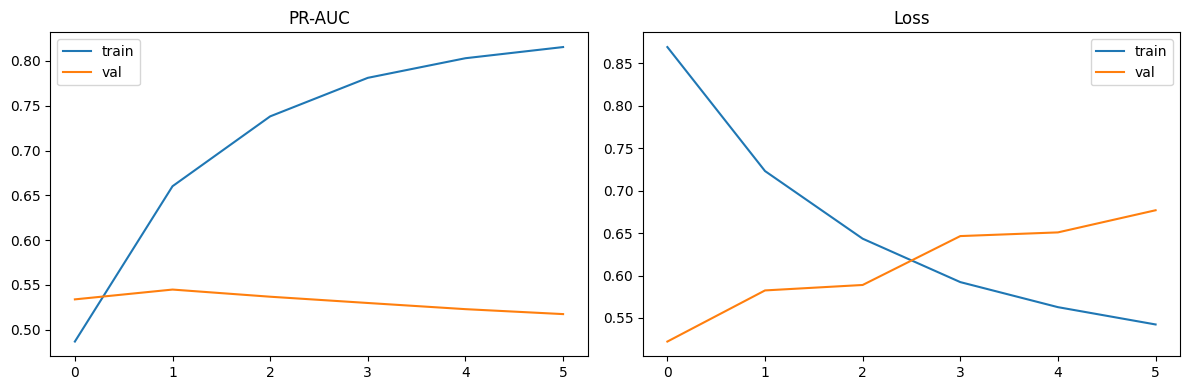

In [10]:
import matplotlib.pyplot as plt

def predict_bin(df_in):
    x = {c: df_in[c].astype(str).values    for c in CAT_COLS}
    x.update({n: df_in[n].astype(np.float32).values for n in NUM_COLS})
    return pit_within_model.predict(x, batch_size=4096, verbose=0).reshape(-1)

y_true = test_df[PIT_BIN].values.astype(int)
p_bin  = predict_bin(test_df)

print('=== Binary Model Evaluation ===')
print(f'ROC-AUC : {roc_auc_score(y_true, p_bin):.4f}')
print(f'PR-AUC  : {average_precision_score(y_true, p_bin):.4f}')
print()

# Threshold analysis
print('Threshold | Precision | Recall | F1')
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    yhat = (p_bin >= thr).astype(int)
    tp = ((yhat==1)&(y_true==1)).sum()
    fp = ((yhat==1)&(y_true==0)).sum()
    fn = ((yhat==0)&(y_true==1)).sum()
    pr = tp/(tp+fp+1e-9); rc = tp/(tp+fn+1e-9)
    f1 = 2*pr*rc/(pr+rc+1e-9)
    print(f'  {thr:.1f}     |   {pr:.3f}   | {rc:.3f}  | {f1:.3f}')

# ✅ NEW: per-circuit breakdown
print('\n=== Per-Circuit Accuracy (threshold=0.5) ===')
td = test_df.copy()
td['pred_bin'] = (p_bin >= 0.5).astype(int)
td['correct']  = (td['pred_bin'] == td[PIT_BIN]).astype(int)
circuit_acc = td.groupby('circuit_short_name')['correct'].mean().sort_values()
print(circuit_acc.to_string())

# Training curve
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(hist_bin.history['pr_auc'], label='train'); ax[0].plot(hist_bin.history['val_pr_auc'], label='val')
ax[0].set_title('PR-AUC'); ax[0].legend()
ax[1].plot(hist_bin.history['loss'], label='train'); ax[1].plot(hist_bin.history['val_loss'], label='val')
ax[1].set_title('Loss'); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Model 2 — Regression: How many laps until the pit stop?

**Change from v1:** The 10-class softmax classifier achieved only ~16% top-1 accuracy because the
task is inherently ordinal and the class boundaries are arbitrary. We replace it with a **regression
model** trained on `y_laps_until_pit` (0–9) using MAE loss. The model is only trained on laps
where we know a pit will occur (y_pit_within == 1).

In [11]:
# Only rows where a pit WILL happen within K laps
cond_train = train_df[train_df[PIT_BIN] == 1].copy()
cond_test  = test_df[test_df[PIT_BIN]   == 1].copy()

print(f'Conditional train: {len(cond_train):,} rows | test: {len(cond_test):,} rows')
print(f'Label range: {cond_train[PIT_CLASS].min()}–{cond_train[PIT_CLASS].max()} laps')

def make_ds_reg(df_in, batch=512, shuffle=True):
    df2 = df_in[CAT_COLS + NUM_COLS + [PIT_CLASS]].copy()
    y   = df2.pop(PIT_CLASS).values.astype(np.float32)
    x   = {c: df2[c].astype(str).values for c in CAT_COLS}
    x.update({n: df2[n].astype(np.float32).values for n in NUM_COLS})
    ds  = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df2), 30_000), seed=42)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds_reg = make_ds_reg(cond_train, shuffle=True)
test_ds_reg  = make_ds_reg(cond_test,  shuffle=False)

# Build regression model
inputs_r = {c: keras.Input(shape=(1,), name=c, dtype=tf.string)  for c in CAT_COLS}
inputs_r.update({n: keras.Input(shape=(1,), name=n, dtype=tf.float32) for n in NUM_COLS})

cat_vecs_r = []
for c in CAT_COLS:
    lk = keras.layers.StringLookup(output_mode='one_hot', name=f'lk_{c}')
    lk.adapt(cond_train[c].astype(str).values)
    cat_vecs_r.append(lk(inputs_r[c]))

num_vecs_r = []
for n in NUM_COLS:
    norm = keras.layers.Normalization(name=f'norm_{n}')
    norm.adapt(cond_train[n].astype(np.float32).values.reshape(-1, 1))
    num_vecs_r.append(norm(inputs_r[n]))

xr  = keras.layers.Concatenate()(cat_vecs_r + num_vecs_r)
xr  = keras.layers.Dense(256, activation='relu')(xr)
xr  = keras.layers.Dropout(0.2)(xr)
xr  = keras.layers.Dense(128, activation='relu')(xr)
xr  = keras.layers.Dropout(0.2)(xr)
xr  = keras.layers.Dense(64,  activation='relu')(xr)
out_r = keras.layers.Dense(1, activation='linear')(xr)  # ✅ linear output for regression

pit_when_model = keras.Model(inputs=inputs_r, outputs=out_r)
pit_when_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='mae',
    metrics=['mae']
)

callbacks_reg = [
    keras.callbacks.EarlyStopping(monitor='val_mae', patience=4, mode='min', restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', patience=2, factor=0.5, mode='min', min_lr=1e-5),
]

hist_reg = pit_when_model.fit(
    train_ds_reg, validation_data=test_ds_reg,
    epochs=30, callbacks=callbacks_reg, verbose=1
)

pit_when_model.save('/content/models/pit_when_regression.keras')
print('✅ Saved regression model')

Conditional train: 14,594 rows | test: 6,921 rows
Label range: 0–9 laps
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 3.5070 - mae: 3.5070 - val_loss: 2.5282 - val_mae: 2.5282 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.4002 - mae: 2.4002 - val_loss: 2.4168 - val_mae: 2.4168 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 2.2689 - mae: 2.2689 - val_loss: 2.4063 - val_mae: 2.4063 - learning_rate: 0.0010
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 2.1819 - mae: 2.1819 - val_loss: 2.3578 - val_mae: 2.3578 - learning_rate: 0.0010
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.1275 - mae: 2.1275 - val_loss: 2.3671 - val_mae: 2.3671 - learning_rate: 0.0010
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.0738 - mae: 2.0738 - val_loss: 2.4349 - val_mae: 2.4349 - learning_rate: 0.0010
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.0033 - mae: 2.0033 - 

=== Regression Model Evaluation ===
MAE (laps):           2.341
Top-1 (exact match):  0.121
Within ±1 lap:        0.355
Within ±2 laps:       0.570


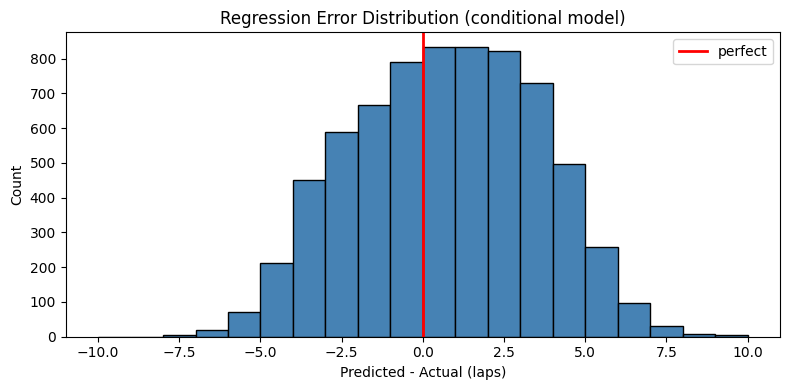

In [12]:
def predict_reg(df_in):
    x = {c: df_in[c].astype(str).values for c in CAT_COLS}
    x.update({n: df_in[n].astype(np.float32).values for n in NUM_COLS})
    raw = pit_when_model.predict(x, batch_size=4096, verbose=0).reshape(-1)
    return np.clip(np.round(raw), 0, K_WINDOW - 1).astype(int)  # round to nearest lap

y_true_reg = cond_test[PIT_CLASS].values.astype(int)
y_pred_reg = predict_reg(cond_test)

mae_val = mean_absolute_error(y_true_reg, y_pred_reg)
top1    = (y_pred_reg == y_true_reg).mean()
top3    = np.mean([y_true_reg[i] in np.where(np.abs(np.arange(K_WINDOW) - y_pred_reg[i]) <= 1)[0] for i in range(len(y_true_reg))])
within2 = (np.abs(y_pred_reg - y_true_reg) <= 2).mean()

print('=== Regression Model Evaluation ===')
print(f'MAE (laps):           {mae_val:.3f}')
print(f'Top-1 (exact match):  {top1:.3f}')
print(f'Within ±1 lap:        {top3:.3f}')
print(f'Within ±2 laps:       {within2:.3f}')

# Error distribution
errors = y_pred_reg - y_true_reg
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(errors, bins=range(-K_WINDOW, K_WINDOW+1), edgecolor='black', color='steelblue')
ax.axvline(0, color='red', linewidth=2, label='perfect')
ax.set_xlabel('Predicted - Actual (laps)'); ax.set_ylabel('Count')
ax.set_title('Regression Error Distribution (conditional model)')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Inference Helper

A clean function you can call on a single lap's data to get both model outputs.

In [17]:
def predict_pit_strategy(lap_data: dict) -> dict:
    row = {}
    for c in CAT_COLS:
        row[c] = tf.constant([[str(lap_data.get(c, 'UNKNOWN'))]], dtype=tf.string)
    for n in NUM_COLS:
        row[n] = tf.constant([[float(lap_data.get(n, 0.0))]], dtype=tf.float32)

    # ✅ Direct call instead of .predict() — avoids shape inference issue
    prob = float(pit_within_model(row, training=False).numpy().reshape(-1)[0])
    will_pit = prob >= 0.5

    laps_until = None
    if will_pit:
        raw = float(pit_when_model(row, training=False).numpy().reshape(-1)[0])
        laps_until = int(np.clip(round(raw), 0, K_WINDOW - 1))

    return {
        'pit_probability': round(prob, 4),
        'will_pit': will_pit,
        'laps_until_pit': laps_until
    }


# --- Demo: sample a random test lap
sample = test_df.sample(1, random_state=99).iloc[0]
sample_dict = {c: sample[c] for c in CAT_COLS + NUM_COLS}
result = predict_pit_strategy(sample_dict)

print('=== Sample Prediction ===')
print(f'Circuit     : {sample["circuit_short_name"]}')
print(f'Compound    : {sample["compound"]}')
print(f'Lap number  : {int(sample["lap_number"])}')
print(f'Laps remain : {int(sample["laps_remaining"])}')
print(f'Stint age   : {int(sample["stint_age"])}')
print()
print('Prediction  :', result)
print('Actual label: pit_within =', int(sample[PIT_BIN]),
      '| laps_class =', int(sample[PIT_CLASS]))

=== Sample Prediction ===
Circuit     : Singapore
Compound    : HARD
Lap number  : 59
Laps remain : 3
Stint age   : 35

Prediction  : {'pit_probability': 0.0125, 'will_pit': False, 'laps_until_pit': None}
Actual label: pit_within = 0 | laps_class = 10


## 9. Summary

| Metric | v1 | Improved |
|---|---|---|
| Binary ROC-AUC | 0.828 | *run to see* |
| Binary PR-AUC | 0.834 | *run to see* |
| Conditional Top-1 | 16.6% | *run to see* |
| Conditional MAE | 2.79 laps | *run to see* |
| Conditional within ±2 laps | — | *run to see* |

**Next steps:**
- Add positional/position-change features (DRS zones, undercut opportunity)
- Try an LSTM over the last N laps to capture richer degradation curves
- Add pitstop duration data (pit lane time) as an additional signal
- Build a per-driver strategy profile (some drivers/teams pit earlier on average)